# Qualitative Code Analysis — Tier Comparison

The first qualitative pass restricted attention to the *best algorithm produced under each (feature, format, seed) triple* — 145 algorithms in total. That sample is roughly 1% of the full Stage 3 dataset and may not be representative of how the LLM writes code under each format on average.

This notebook re-runs the AST complexity analysis and the regex-based strategy classification at three tiers so we can compare:

1. **All** — every valid Stage 3 algorithm (~14,127).
2. **Top 10%** — top decile by AOCC within each format (the most informative subset for "what does *good* code look like").
3. **Best-per-cell** — the original 145-algorithm sample, kept here for direct comparability with the thesis draft.

For each tier we report (a) per-format means and Kruskal–Wallis p-values for the 12 AST metrics, (b) Cliff's d effect sizes for the neutral-vs-prescriptive contrasts, and (c) the strategy-prevalence heatmap. The same regex patterns and AST extractor as the original notebook are used, so any tier-level shifts reflect sampling, not method differences.

In [1]:
import sys, json, re, ast, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
from export_figures import (
    FEATURES, FORMATS, FORMAT_COLORS, N_SEEDS,
    FONT_SIZE_BASE, FONT_SIZE_TITLE, FONT_SIZE_LABEL,
    FONT_SIZE_TICK, FONT_SIZE_LEGEND,
    COMPARATIVE_EXCLUDE, RESULTS_PHASE3,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': FONT_SIZE_BASE,
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABEL,
    'xtick.labelsize': FONT_SIZE_TICK,
    'ytick.labelsize': FONT_SIZE_TICK,
    'legend.fontsize': FONT_SIZE_LEGEND,
    'font.family': 'serif',
    'axes.linewidth': 1.2,
})

FMT_ORDER = ['neutral', 'directional', 'comparative']

## 1. Load all Phase 3 candidates with code

In [2]:
def parse_fitness(v):
    try:
        x = float(v)
        return np.nan if (np.isinf(x) and x < 0) else x
    except (TypeError, ValueError):
        return np.nan


def load_phase3_with_code():
    rows = []
    for feat in FEATURES:
        for fmt in FORMATS:
            if fmt == 'comparative' and feat in COMPARATIVE_EXCLUDE:
                continue
            cond = f'{fmt}-{feat}'
            for seed in range(N_SEEDS):
                seed_dir = RESULTS_PHASE3 / cond / f'seed-{seed}'
                runs = sorted(seed_dir.glob('run-*'))
                if not runs:
                    continue
                log = runs[0] / 'log.jsonl'
                if not log.exists():
                    continue
                with open(log) as fh:
                    for i, line in enumerate(fh):
                        e = json.loads(line.strip())
                        f_ = parse_fitness(e.get('fitness'))
                        rows.append({
                            'format': fmt, 'feature': feat, 'seed': seed,
                            'evaluation': i, 'fitness': f_, 'failed': np.isnan(f_),
                            'code': e.get('code', ''),
                        })
    return pd.DataFrame(rows)

df = load_phase3_with_code()
valid = df[~df['failed']].copy()
print(f'Total entries:          {len(df):>6d}')
print(f'Valid (non-failed):     {len(valid):>6d}')
print(f'Per format (valid):')
print(valid['format'].value_counts().to_string())

Total entries:           14500
Valid (non-failed):      14127
Per format (valid):
format
directional    4868
neutral        4827
comparative    4432


## 2. Define tiers

In [3]:
tier_all = valid.copy()

# Top 10% by AOCC *within each format*, so we are comparing the
# best-of-format slices rather than letting one format dominate the tier.
tier_top10 = (
    valid.groupby('format', group_keys=False)
         .apply(lambda g: g.nlargest(int(np.ceil(len(g) * 0.1)), 'fitness'))
         .copy()
)

# Best-per-cell (original 145).
idx = valid.groupby(['feature', 'format', 'seed'])['fitness'].idxmax()
tier_bpc = valid.loc[idx].copy()

TIERS = {
    'all (valid)': tier_all,
    'top 10%': tier_top10,
    'best-per-cell': tier_bpc,
}
for name, t in TIERS.items():
    counts = t['format'].value_counts().reindex(FMT_ORDER)
    total = len(t)
    print(f'{name:<14s}  total={total:>6d}   ' + '  '.join(
        f'{f}={int(counts[f])}' for f in FMT_ORDER
    ))

all (valid)     total= 14127   neutral=4827  directional=4868  comparative=4432
top 10%         total=  1414   neutral=483  directional=487  comparative=444
best-per-cell   total=   145   neutral=50  directional=50  comparative=45


## 3. AST extraction

In [4]:
def ast_metrics(code):
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return None
    m = dict(n_functions=0, n_classes=0, n_for_loops=0, n_while_loops=0,
             n_if_branches=0, n_try_except=0, max_loop_depth=0,
             n_numeric_constants=0, n_string_constants=0, n_np_calls=0,
             n_assignments=0, n_augmented_assigns=0, n_return_statements=0,
             total_ast_nodes=0)

    def walk(node, depth=0):
        m['total_ast_nodes'] += 1
        if isinstance(node, ast.FunctionDef): m['n_functions'] += 1
        elif isinstance(node, ast.ClassDef): m['n_classes'] += 1
        elif isinstance(node, ast.For):
            m['n_for_loops'] += 1
            nd = depth + 1
            m['max_loop_depth'] = max(m['max_loop_depth'], nd)
            for c in ast.iter_child_nodes(node): walk(c, nd)
            return
        elif isinstance(node, ast.While):
            m['n_while_loops'] += 1
            nd = depth + 1
            m['max_loop_depth'] = max(m['max_loop_depth'], nd)
            for c in ast.iter_child_nodes(node): walk(c, nd)
            return
        elif isinstance(node, ast.If): m['n_if_branches'] += 1
        elif isinstance(node, ast.Try): m['n_try_except'] += 1
        elif isinstance(node, ast.Assign): m['n_assignments'] += 1
        elif isinstance(node, ast.AugAssign): m['n_augmented_assigns'] += 1
        elif isinstance(node, ast.Return): m['n_return_statements'] += 1
        elif isinstance(node, ast.Constant):
            if isinstance(node.value, (int, float)): m['n_numeric_constants'] += 1
            elif isinstance(node.value, str): m['n_string_constants'] += 1
        elif isinstance(node, ast.Call):
            if isinstance(node.func, ast.Attribute) and isinstance(node.func.value, ast.Name) and node.func.value.id == 'np':
                m['n_np_calls'] += 1
        for c in ast.iter_child_nodes(node):
            walk(c, depth)

    walk(tree)
    return m


def cliffs_d(x, y):
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0: return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


def cliffs_d_fast(x, y):
    """O((n+m) log(n+m)) Cliff's delta via rank trick."""
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    combined = np.concatenate([x, y])
    ranks = sp_stats.rankdata(combined, method='average')
    r_x_sum = ranks[:n_x].sum()
    u_x = r_x_sum - n_x * (n_x + 1) / 2
    return 2 * u_x / (n_x * n_y) - 1

## 4. AST analysis per tier
Compute every metric over every algorithm in each tier. Parse failures (rare on Stage 3 Gemini code, since the algorithm is invoked successfully) are dropped. Print per-format mean ± std plus the Kruskal–Wallis p-value across the three formats and Cliff's d for the neutral-vs-prescriptive contrasts.

In [5]:
AST_COLS = [
    'total_ast_nodes', 'n_np_calls', 'n_numeric_constants', 'n_assignments',
    'n_try_except', 'n_functions', 'n_for_loops', 'n_while_loops',
    'n_if_branches', 'max_loop_depth', 'n_augmented_assigns',
    'n_return_statements',
]

ast_cache = {}

def parse_tier(tier_df, label):
    if label in ast_cache:
        return ast_cache[label]
    rows = []
    for _, r in tier_df.iterrows():
        m = ast_metrics(r['code'])
        if m is None:
            continue
        m['format'] = r['format']
        m['feature'] = r['feature']
        m['seed'] = r['seed']
        m['fitness'] = r['fitness']
        rows.append(m)
    out = pd.DataFrame(rows)
    ast_cache[label] = out
    return out

ast_results = {label: parse_tier(t, label) for label, t in TIERS.items()}
for label, a in ast_results.items():
    print(f'{label:<14s}  parsed {len(a):>6d} / {len(TIERS[label]):>6d}')

all (valid)     parsed  14127 /  14127
top 10%         parsed   1414 /   1414
best-per-cell   parsed    145 /    145


In [6]:
def ast_summary(ast_df):
    rows = []
    for col in AST_COLS:
        row = {'metric': col}
        vals_by_fmt = []
        for f in FMT_ORDER:
            v = ast_df[ast_df['format'] == f][col]
            row[f'{f}_mean'] = v.mean()
            row[f'{f}_std'] = v.std()
            row[f'{f}_n'] = len(v)
            vals_by_fmt.append(v.values)
        H, p = sp_stats.kruskal(*vals_by_fmt)
        row['p_kw'] = p
        row['d_n_d'] = cliffs_d_fast(vals_by_fmt[0], vals_by_fmt[1])
        row['d_n_c'] = cliffs_d_fast(vals_by_fmt[0], vals_by_fmt[2])
        rows.append(row)
    return pd.DataFrame(rows)

summaries = {label: ast_summary(a) for label, a in ast_results.items()}

for label, s in summaries.items():
    print(f'\n=== {label.upper()} ({len(ast_results[label])} algorithms) ===')
    cols = ['metric',
            'neutral_mean', 'neutral_std',
            'directional_mean', 'directional_std',
            'comparative_mean', 'comparative_std',
            'p_kw', 'd_n_d', 'd_n_c']
    disp = s[cols].copy()
    fmt_map = {
        'neutral_mean': '%.1f', 'neutral_std': '%.1f',
        'directional_mean': '%.1f', 'directional_std': '%.1f',
        'comparative_mean': '%.1f', 'comparative_std': '%.1f',
        'p_kw': '%.4f', 'd_n_d': '%+.3f', 'd_n_c': '%+.3f',
    }
    for c, fmt in fmt_map.items():
        disp[c] = disp[c].apply(lambda x: fmt % x)
    print(disp.to_string(index=False))


=== ALL (VALID) (14127 algorithms) ===
             metric neutral_mean neutral_std directional_mean directional_std comparative_mean comparative_std   p_kw  d_n_d  d_n_c
    total_ast_nodes       1404.4       401.0           1262.3           382.6           1145.2           409.3 0.0000 +0.193 +0.384
         n_np_calls         26.6        11.2             23.4            10.0             19.5             9.5 0.0000 +0.152 +0.375
n_numeric_constants         70.2        32.7             63.1            26.6             58.6            24.1 0.0000 +0.078 +0.145
      n_assignments         67.5        15.9             63.3            16.2             58.0            15.7 0.0000 +0.152 +0.355
       n_try_except          0.5         0.6              0.3             0.6              0.2             0.4 0.0000 +0.198 +0.279
        n_functions          2.6         0.8              2.4             0.8              2.4             0.8 0.0000 +0.086 +0.119
        n_for_loops          2.4    

## 5. Side-by-side significance summary
Show each tier's significant metrics in one place, so you can see at a glance whether the AST signal survives at scale.

In [7]:
sig_rows = []
for col in AST_COLS:
    row = {'metric': col}
    for label, s in summaries.items():
        srow = s[s['metric'] == col].iloc[0]
        row[f'{label} p'] = f"{srow['p_kw']:.4f}"
        row[f'{label} d(N-C)'] = f"{srow['d_n_c']:+.3f}"
    sig_rows.append(row)
sig_df = pd.DataFrame(sig_rows)
print('Kruskal–Wallis p (across formats) and Cliff\'s d (neutral vs comparative) per tier:\n')
print(sig_df.to_string(index=False))

Kruskal–Wallis p (across formats) and Cliff's d (neutral vs comparative) per tier:

             metric all (valid) p all (valid) d(N-C) top 10% p top 10% d(N-C) best-per-cell p best-per-cell d(N-C)
    total_ast_nodes        0.0000             +0.384    0.0000         +0.290          0.0065               +0.342
         n_np_calls        0.0000             +0.375    0.0000         +0.292          0.0006               +0.432
n_numeric_constants        0.0000             +0.145    0.0000         +0.324          0.0130               +0.327
      n_assignments        0.0000             +0.355    0.0000         +0.209          0.0363               +0.300
       n_try_except        0.0000             +0.279    0.0000         +0.188          0.0006               +0.375
        n_functions        0.0000             +0.119    0.0000         -0.018          0.1223               +0.180
        n_for_loops        0.0000             +0.200    0.0020         +0.113          0.1284               +0.

## 6. AST boxplots — one row per tier

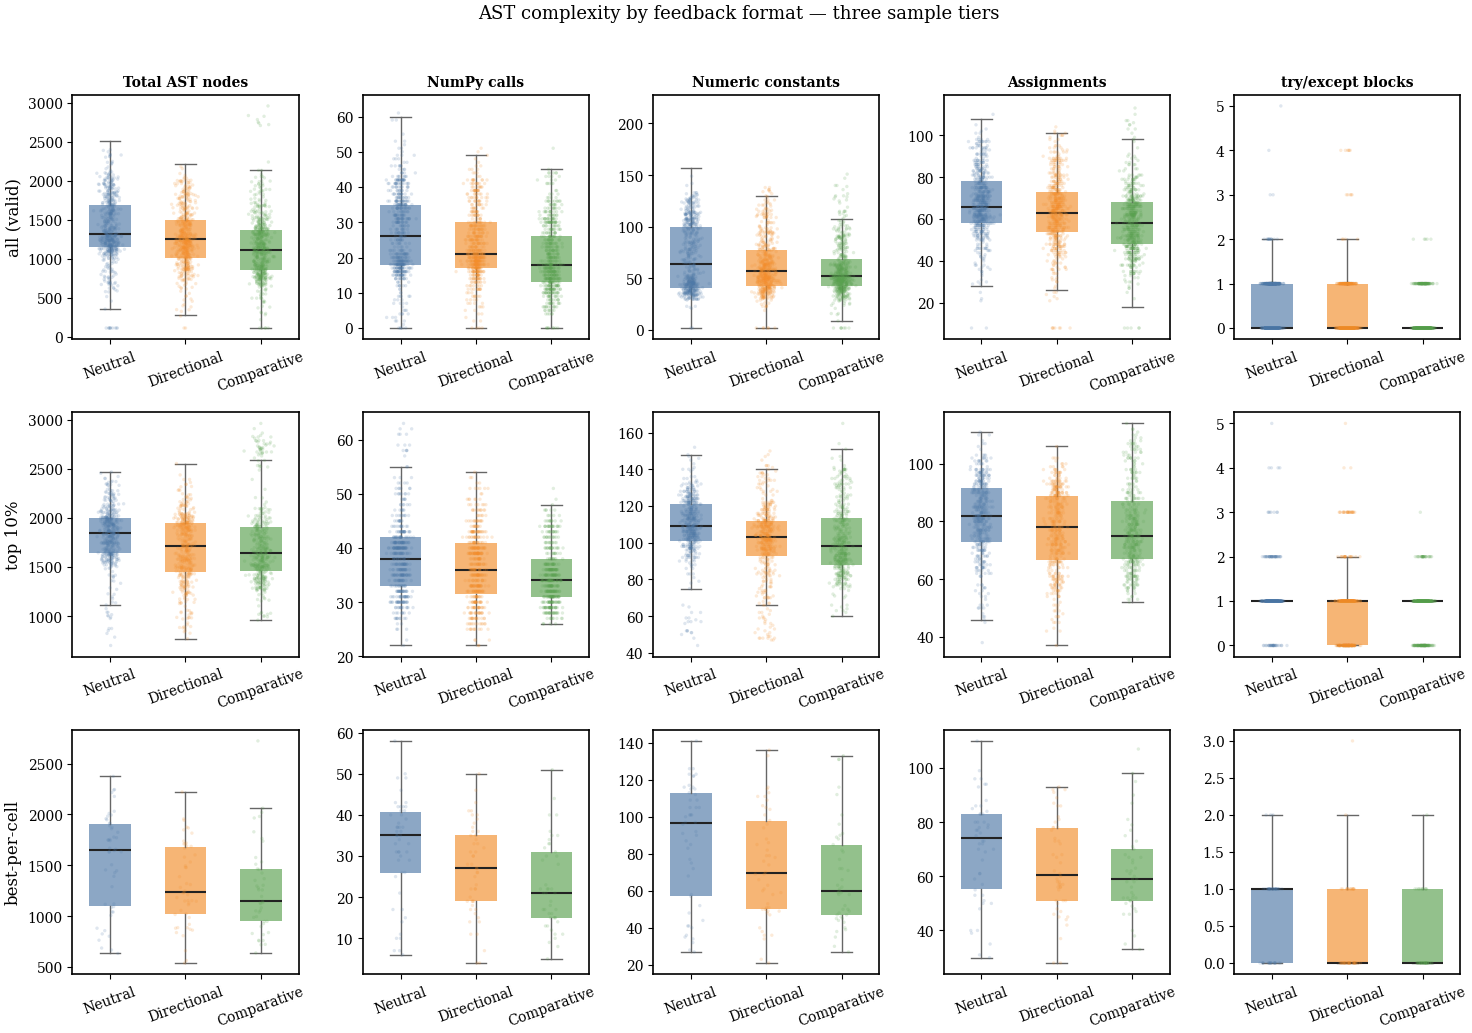

In [8]:
FOCUS = [
    ('total_ast_nodes', 'Total AST nodes'),
    ('n_np_calls', 'NumPy calls'),
    ('n_numeric_constants', 'Numeric constants'),
    ('n_assignments', 'Assignments'),
    ('n_try_except', 'try/except blocks'),
]

fig, axes = plt.subplots(len(TIERS), len(FOCUS),
                         figsize=(15, 3.4 * len(TIERS)),
                         sharey=False)
rng = np.random.default_rng(42)
for row_i, (label, ast_df) in enumerate(ast_results.items()):
    for col_i, (col, name) in enumerate(FOCUS):
        ax = axes[row_i, col_i]
        data_by = [ast_df[ast_df['format'] == f][col].values for f in FMT_ORDER]
        bp = ax.boxplot(
            data_by, labels=[f.capitalize() for f in FMT_ORDER],
            patch_artist=True, widths=0.55,
            medianprops=dict(color='#222', linewidth=1.5),
            whiskerprops=dict(color='#666'),
            capprops=dict(color='#666'),
            flierprops=dict(marker='none'))
        for patch, fmt in zip(bp['boxes'], FMT_ORDER):
            patch.set_facecolor(FORMAT_COLORS[fmt])
            patch.set_edgecolor('none')
            patch.set_alpha(0.65)
        # Subsample scatter for the giant 'all' tier
        for i, fmt in enumerate(FMT_ORDER):
            v = ast_df[ast_df['format'] == fmt][col].values
            if len(v) > 600:
                v = rng.choice(v, size=600, replace=False)
            j = rng.normal(0, 0.06, size=len(v))
            ax.scatter(np.full_like(v, i + 1, dtype=float) + j, v,
                       alpha=0.18, s=6, color=FORMAT_COLORS[fmt],
                       edgecolor='none', zorder=3)
        ax.tick_params(axis='x', rotation=20)
        if row_i == 0:
            ax.set_title(name, fontsize=FONT_SIZE_TICK, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(label, fontsize=FONT_SIZE_LABEL)
fig.suptitle('AST complexity by feedback format — three sample tiers',
             fontsize=FONT_SIZE_TITLE, y=1.02)
plt.tight_layout()
plt.show()

## 7. Strategy classification per tier

In [9]:
STRATEGY_PATTERNS = {
    'CMA-ES': r'cma|covariance[\s_]matrix|cholesky|evolution[\s_]path',
    'BIPOP / Restart': r'bipop|restart|reboot|reinitiali',
    'Differential Evolution': r'differential[\s_]evolution|de[\s_]|donor[\s_]|trial[\s_]vector|cr[\s_]=|f[\s_]=.*rand',
    'Particle Swarm': r'particle|swarm|velocity|pbest|gbest|cognitive.*social',
    'Natural ES (SNES/xNES)': r'natural[\s_]evolution|snes|xnes|openai[\s_]es|log[\s_]sigma',
    'Simulated Annealing': r'anneal|temperature[\s_]*[*=]|cooling|metropolis|boltzmann',
    'Genetic Algorithm': r'crossover|recombination|tournament[\s_]select|mating',
    'Local Search': r'local[\s_]search|nelder[\s_]mead|powell|simplex[\s_]|golden[\s_]section',
    'Adaptive Step Size': r'sigma[\s_]*[*]=|step[\s_]size[\s_]*adapt|1[./]5[\s_]rule|success[\s_]rule|adapt.*sigma',
    'Levy / Heavy-Tail': r'levy|cauchy[\s_]|heavy[\s_]tail|alpha[\s_]stable',
    'Surrogate / Bayesian': r'surrogate|gaussian[\s_]process|acquisition|bayesian|kriging',
    'Multi-Population': r'island|migration|sub[\s_]*pop|multi[\s_]*pop|archipelago',
    'Population-Based': r'population|pop_size|pop[\s_]*=|n_pop|lambda[\s_]*=|popsize',
}

def strategy_table(tier_df):
    rows = []
    for _, r in tier_df.iterrows():
        cl = r['code'].lower()
        d = {n: bool(re.search(p, cl)) for n, p in STRATEGY_PATTERNS.items()}
        d['format'] = r['format']
        rows.append(d)
    return pd.DataFrame(rows)

strat_results = {label: strategy_table(t) for label, t in TIERS.items()}
for label, s in strat_results.items():
    print(f'\n=== {label.upper()} (n = {len(s)}) ===')
    f = s.groupby('format')[list(STRATEGY_PATTERNS)].mean().reindex(FMT_ORDER)
    print(f.T.round(3).to_string())


=== ALL (VALID) (n = 14127) ===
format                  neutral  directional  comparative
CMA-ES                    0.553        0.538        0.616
BIPOP / Restart           0.557        0.598        0.620
Differential Evolution    0.781        0.653        0.541
Particle Swarm            0.486        0.439        0.330
Natural ES (SNES/xNES)    0.068        0.114        0.099
Simulated Annealing       0.000        0.001        0.001
Genetic Algorithm         0.613        0.528        0.375
Local Search              0.159        0.269        0.175
Adaptive Step Size        0.502        0.515        0.605
Levy / Heavy-Tail         0.234        0.169        0.118
Surrogate / Bayesian      0.000        0.000        0.000
Multi-Population          0.001        0.000        0.000
Population-Based          0.945        0.747        0.528

=== TOP 10% (n = 1414) ===
format                  neutral  directional  comparative
CMA-ES                    0.992        0.920        1.000
BIPOP / Res

## 8. Strategy heatmaps — one panel per tier

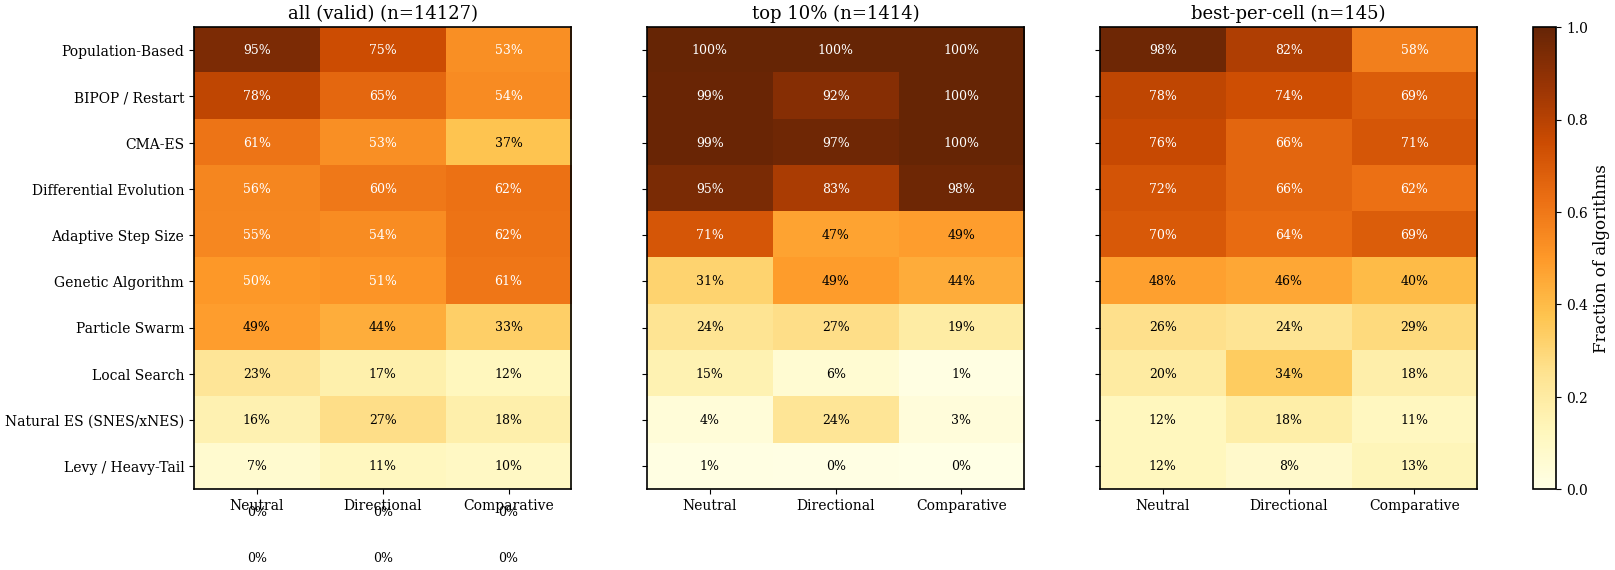

In [10]:
fig, axes = plt.subplots(1, len(strat_results),
                         figsize=(6 * len(strat_results), 6),
                         sharey=True)
for ax, (label, s) in zip(axes, strat_results.items()):
    freq = s.groupby('format')[list(STRATEGY_PATTERNS)].mean().reindex(FMT_ORDER)
    present = [c for c in STRATEGY_PATTERNS if freq[c].sum() > 0]
    freq = freq[present]
    order = freq.loc['neutral'].sort_values(ascending=False).index.tolist()
    data = freq[order].T.values
    im = ax.imshow(data, cmap='YlOrBr', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(FMT_ORDER)))
    ax.set_xticklabels([f.capitalize() for f in FMT_ORDER])
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_title(f'{label} (n={len(s)})')
    for i in range(len(order)):
        for j in range(len(FMT_ORDER)):
            v = data[i, j]
            col = 'white' if v > 0.5 else 'black'
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color=col)
fig.colorbar(im, ax=axes, fraction=0.04, pad=0.04, label='Fraction of algorithms')
plt.show()

## 9. Strategy significance per tier (Fisher exact, neutral vs comparative)

In [11]:
rows = []
for label, s in strat_results.items():
    sub_n = s[s['format'] == 'neutral']
    sub_c = s[s['format'] == 'comparative']
    for strat in STRATEGY_PATTERNS:
        a = int(sub_n[strat].sum()); b = len(sub_n) - a
        c = int(sub_c[strat].sum()); d = len(sub_c) - c
        if a + c == 0:
            continue
        try:
            _, p = sp_stats.fisher_exact([[a, b], [c, d]])
        except ValueError:
            p = np.nan
        rows.append({
            'tier': label, 'strategy': strat,
            'neutral %': a / max(len(sub_n), 1),
            'comparative %': c / max(len(sub_c), 1),
            'p': p,
        })
tab = pd.DataFrame(rows)
for label in TIERS:
    sub = tab[tab['tier'] == label].copy()
    sub_disp = sub[['strategy', 'neutral %', 'comparative %', 'p']].copy()
    sub_disp['neutral %'] = (sub_disp['neutral %'] * 100).round(1)
    sub_disp['comparative %'] = (sub_disp['comparative %'] * 100).round(1)
    sub_disp['p'] = sub_disp['p'].apply(lambda x: f'{x:.4f}')
    sub_disp['sig'] = sub['p'].apply(lambda x: '*' if x < 0.05 else '')
    print(f'\n=== {label.upper()} ===')
    print(sub_disp.to_string(index=False))


=== ALL (VALID) ===
              strategy  neutral %  comparative %      p sig
                CMA-ES       55.3           61.6 0.0000   *
       BIPOP / Restart       55.7           62.0 0.0000   *
Differential Evolution       78.1           54.1 0.0000   *
        Particle Swarm       48.6           33.0 0.0000   *
Natural ES (SNES/xNES)        6.8            9.9 0.0000   *
   Simulated Annealing        0.0            0.1 0.0525    
     Genetic Algorithm       61.3           37.5 0.0000   *
          Local Search       15.9           17.5 0.0416   *
    Adaptive Step Size       50.2           60.5 0.0000   *
     Levy / Heavy-Tail       23.4           11.8 0.0000   *
      Multi-Population        0.1            0.0 0.4559    
      Population-Based       94.5           52.8 0.0000   *

=== TOP 10% ===
              strategy  neutral %  comparative %      p sig
                CMA-ES       99.2          100.0 0.1255    
       BIPOP / Restart      100.0          100.0 1.0000    
Di

## 10. Discussion prompts

After running, consider:

- **Does the neutral > directional > comparative AST gap survive at the all-valid scale?** If so, the original 145-algorithm story holds and we have stronger statistical power. If the gap shrinks or flips, the best-per-cell view was a winner-curse artifact.
- **Does the top-10% tier change the story?** This tier is roughly the population that *matters* — algorithms close to the per-format peak. If neutral's complexity advantage shows up here too, we can frame it as "better neutral algorithms are more elaborate" rather than "all neutral algorithms are".
- **Which tier gives the cleanest strategy heatmap?** With more data, the family-level percentages stabilise and the neutral-comparative gap on population-based methods (98% vs 58% in best-per-cell) may move.
- **Cost of switching to a wider tier.** Parsing 14k algorithms is fine but the boxplot scatter at all-valid scale will be dense; the figure may need a different visualisation (violin or histogram) to stay legible.

Pick the tier whose narrative best matches what you want to claim, then we can rewrite section 5.3 around it.